### <font size=5>**Medical Named Entity Recognition and Treatment Extraction using Conditional Random Fields**</font>
***

#### <font color='#000080' size=5>***Project Overview:***</font>

</br>
<font size=3 font-family:"Calibri">
Healthcare organizations generate large volumes of unstructured clinical text containing valuable information about diseases, symptoms, medications, and treatment procedures. Extracting this information manually is time-consuming and difficult to scale.
</br>
</br>
This project develops a Natural Language Processing (NLP) pipeline capable of automatically identifying disease entities and their associated treatments from medical text using Conditional Random Fields (CRF).
</br>
</br>
The extracted disease-treatment relationships can support clinical decision support systems, medical knowledge discovery, and healthcare information retrieval applications.
</br>
</br> 
</font>
</br>

#### <font color='#000080' size=5>***Business Problem:***</font>
</br>
<font size=3 font-family:"Calibri">
A healthcare information platform stores large volumes of unstructured medical text containing references to diseases and treatments.
The objective is to automatically identify:
</br>    
1. Disease entities mentioned within clinical text. </br>
2. Treatment entities associated with those diseases. </br>
3. Disease-treatment relationships that can be used to construct a structured medical knowledge base. </br>
</br>
The solution should transform unstructured text into actionable and searchable healthcare information.    
</font>

#### <font color='#000080' size=5>***Objective:***</font>
</br>
<font size=3 font-family:"Calibri">
1. Convert token-level medical datasets into sentence format. </br>
2. Perform linguistic analysis using POS tagging.</br>
3. Engineer contextual and lexical features for sequence labeling.</br>
4. Train a Conditional Random Fields model for Named Entity Recognition.</br>
5. Evaluate entity extraction performance using F1 Score.</br>
6. Extract disease-treatment relationships from medical text.</br>
7. Create a searchable disease-treatment dictionary.</br>
</font>

#### <font color='#000080' size=5>***1. Data preprocessing:***</font>

#### 1.1 Import the required Libraries

In [15]:
import spacy
import sklearn_crfsuite
from sklearn_crfsuite import metrics
import pandas as pd

#### 1.2 Load Spacy model "en_core_web_sm"

In [17]:
model = spacy.load("en_core_web_sm")

The dataset provided is in the form of one word per line. Let's understand the format of data below:
- Suppose there are *x* words in a sentence, then there will be *x* continuous lines with one word in each line. 
- Further, the two sentences are separated by empty lines. The labels for the data follow the same format.

We need to pre-process the data to recover the complete sentences and their labels.

#### 1.3 Data Sourcing

**Construct proper sentences from individual words and print five sentences along with their labels.**

In [21]:
def extract_data(filename):
    input_file = open(filename, 'r')
    file_content = input_file.readlines()
    input_file.close()

    #Store the list of sentences in the input file to sentence_list
    sentence_list = []

    sentence = ""
    for word in file_content:
        word = word.strip()
        if word == "": # If empty line, add the current sequence to sentence_list
            sentence_list.append(sentence)
            sentence="" #Reinitialize
        else:
            if sentence:
                sentence += " "+word #if non-empty, add new word after space
            else:
                sentence = word # first word, hence no space required
    return sentence_list

In [22]:
train_sentences = extract_data('train_sent')
train_labels = extract_data('train_label')
test_sentences = extract_data('test_sent')
test_labels = extract_data('test_label')

In [23]:
# Print the 5 sentences from the training dataset
print("---------------------- Training Dataset -----------------")
for i in range(5):
  print("Sentence:", train_sentences[i])
  print("Labels:", train_labels[i], "\n\n")

---------------------- Training Dataset -----------------
Sentence: All live births > or = 23 weeks at the University of Vermont in 1995 ( n = 2395 ) were retrospectively analyzed for delivery route , indication for cesarean , gestational age , parity , and practice group ( to reflect risk status )
Labels: O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O 


Sentence: The total cesarean rate was 14.4 % ( 344 of 2395 ) , and the primary rate was 11.4 % ( 244 of 2144 )
Labels: O O O O O O O O O O O O O O O O O O O O O O O O O 


Sentence: Abnormal presentation was the most common indication ( 25.6 % , 88 of 344 )
Labels: O O O O O O O O O O O O O O O 


Sentence: The `` corrected '' cesarean rate ( maternal-fetal medicine and transported patients excluded ) was 12.4 % ( 273 of 2194 ) , and the `` corrected '' primary rate was 9.6 % ( 190 of 1975 )
Labels: O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O 


Sentence: Arres

In [24]:
# Print the 5 sentences from the test dataset
print("---------------------- Test Dataset -----------------")
for i in range(5):
  print("Sentence:", test_sentences[i])
  print("Labels:", test_labels[i], "\n\n")

---------------------- Test Dataset -----------------
Sentence: Furthermore , when all deliveries were analyzed , regardless of risk status but limited to gestational age > or = 36 weeks , the rates did not change ( 12.6 % , 280 of 2214 ; primary 9.2 % , 183 of 1994 )
Labels: O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O 


Sentence: As the ambient temperature increases , there is an increase in insensible fluid loss and the potential for dehydration
Labels: O O O O O O O O O O O O O O O O O O O 


Sentence: The daily high temperature ranged from 71 to 104 degrees F and AFI values ranged from 1.7 to 24.7 cm during the study period
Labels: O O O O O O O O O O O O O O O O O O O O O O O O 


Sentence: There was a significant correlation between the 2- , 3- , and 4-day mean temperature and AFI , with the 4-day mean being the most significant ( r = 0.31 , p & # 60 ; 0.001 )
Labels: O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O O 

#### 1.4 Understanding Dataset

**Print the correct count of the number of sentences in the processed train and test dataset.**

In [27]:
print("No. of lines in train_sentences:", len(train_sentences))
print("No. of lines in test_sentences:", len(test_sentences))

No. of lines in train_sentences: 2599
No. of lines in test_sentences: 1056


**Correctly count the number of lines of labels in the processed train and test dataset.**

In [29]:
# The lengths of the sentences above in train and test data should match with the lengths of the labels
print("No. of lines in train_labels:", len(train_labels))
print("No. of lines in test_labels:", len(test_labels))

No. of lines in train_labels: 2599
No. of lines in test_labels: 1056


#### <font color='#000080' size=5>***2. Concept Identification:***</font>

NOTE: This is an exploratory analysis on the complete data. Since we are not training anything, there is no point is discarding information in test data. Hence we shall identify the concepts from both train and test data

#### 2.1 Extract those tokens which have NOUN or PROPN as their PoS tag and find their frequency

In [33]:
concepts = {}
for sentences in (train_sentences, test_sentences):
    for sentence in sentences:
        processed_sentence = model(sentence) # Process each sentence by spacy model
        for token in processed_sentence:
            if(token.pos_ == 'NOUN' or token.pos_ == 'PROPN'):
                concepts[token.text] = concepts.get(token.text, 0) + 1; #increase its frequency if it is noun

In [34]:
first5pairs = {k: concepts[k] for k in list(concepts)[:5]}
first5pairs

{'births': 2, 'weeks': 37, 'University': 6, 'Vermont': 1, 'delivery': 20}

#### 2.2 Print the top 25 most common tokens with NOUN or PROPN PoS tags

In [36]:
from collections import Counter
concept_counter = Counter(concepts)
concept_counter.most_common(25)

[('patients', 492),
 ('treatment', 281),
 ('%', 247),
 ('cancer', 200),
 ('therapy', 175),
 ('study', 154),
 ('disease', 142),
 ('cell', 140),
 ('lung', 116),
 ('group', 94),
 ('chemotherapy', 88),
 ('gene', 87),
 ('effects', 85),
 ('results', 79),
 ('women', 77),
 ('use', 74),
 ('TO_SEE', 74),
 ('risk', 71),
 ('cases', 71),
 ('surgery', 71),
 ('analysis', 70),
 ('rate', 67),
 ('response', 66),
 ('survival', 65),
 ('children', 64)]

#### <font color='#000080' size=5>***3. Features for CRF:***</font>

1. Define the features with the PoS tag as one of the features.
2. Consider the preceding word of the current word. The use of the information of the preceding word makes the CRF model more accurate and exhaustive.
3. Mark the beginning and the end words of a sentence correctly in the form of features.

In [39]:
def getFeaturesForOneWord(sentence, pos, pos_tags):
    word = sentence[pos]

    features = [
        'word.lower=' + word.lower(),  # serves as word id
        'word[-3:]=' + word[-3:], # last three characters
        'word[-2:]=' + word[-2:], # last two characters
        'word.isupper=%s' % word.isupper(), # is the word in all uppercase
        'word.isdigit=%s' % word.isdigit(), # is the word a number
        'word.startsWithCapital=%s' % word[0].isupper(), # is the word starting with a capital letter
        'word.pos=' + pos_tags[pos] #POS tags
    ]

    #Use the previous word also while defining features
    if(pos > 0):
        prev_word = sentence[pos-1]
        features.extend([
            'prev_word.lower=' + prev_word.lower(), 
            'prev_word.isupper=%s' % prev_word.isupper(),
            'prev_word.isdigit=%s' % prev_word.isdigit(),
            'prev_word.startsWithCapital=%s' % prev_word[0].isupper(),
            'prev_word.pos=' + pos_tags[pos-1]
        ])

    # Mark the begining and the end words of a sentence correctly in the form of features.
    else:
        features.append('BEG') # feature to track begin of sentence 

    if(pos == len(sentence)-1):
        features.append('END') # feature to track end of sentence

    return features

#### <font color='#000080' size=5>***4. Feature word and sentences:***</font>

#### 4.1 Get the features value of a sentence after defining the features in the previous step.

In [42]:
def getFeaturesForOneSentence(sentence):
    processed_sentence = model(sentence)  #spacy model is applied

    pos_tags = []
    for token in processed_sentence:
        pos_tags.append(token.pos_)

    sentence_list = sentence.split() # List of words in sentence

    return [getFeaturesForOneWord(sentence_list, pos, pos_tags) for pos in range(len(sentence_list))]

#### 4.2 Get a list of labels of a given preprocessed label line that you have created earlier.

In [44]:
def getLabelsInListForOneSentence(labels):
  return labels.split()

#### <font color='#000080' size=5>***5. Input and Target variables:***</font>

#### 5.1 Extract the features values for each sentence as an input variable for the CRF model in the test and the train dataset.

In [47]:
X_train = [getFeaturesForOneSentence(sentence) for sentence in train_sentences]
X_test = [getFeaturesForOneSentence(sentence) for sentence in test_sentences]

In [48]:
X_train[:1]

[[['word.lower=all',
   'word[-3:]=All',
   'word[-2:]=ll',
   'word.isupper=False',
   'word.isdigit=False',
   'word.startsWithCapital=True',
   'word.pos=DET',
   'BEG'],
  ['word.lower=live',
   'word[-3:]=ive',
   'word[-2:]=ve',
   'word.isupper=False',
   'word.isdigit=False',
   'word.startsWithCapital=False',
   'word.pos=ADJ',
   'prev_word.lower=all',
   'prev_word.isupper=False',
   'prev_word.isdigit=False',
   'prev_word.startsWithCapital=True',
   'prev_word.pos=DET'],
  ['word.lower=births',
   'word[-3:]=ths',
   'word[-2:]=hs',
   'word.isupper=False',
   'word.isdigit=False',
   'word.startsWithCapital=False',
   'word.pos=NOUN',
   'prev_word.lower=live',
   'prev_word.isupper=False',
   'prev_word.isdigit=False',
   'prev_word.startsWithCapital=False',
   'prev_word.pos=ADJ'],
  ['word.lower=>',
   'word[-3:]=>',
   'word[-2:]=>',
   'word.isupper=False',
   'word.isdigit=False',
   'word.startsWithCapital=False',
   'word.pos=X',
   'prev_word.lower=births',
   'p

#### 5.2 Extract the labels as the target variable for the test and the train dataset.

In [50]:
y_train = [getLabelsInListForOneSentence(labels) for labels in train_labels]
y_test = [getLabelsInListForOneSentence(labels) for labels in test_labels]

#### <font color='#000080' size=5>***6. Model Building:***</font>

In [52]:
# Build the CRF model.

crf = sklearn_crfsuite.CRF(max_iterations=100)
try:
    crf.fit(X_train, y_train)
except:
    print("Please check the arguments passed to the fit function.")

#### <font color='#000080' size=5>***7. Model Evaluation:***</font>

#### 7.1 Predict the labels of each of the tokens in each sentence of the test dataset that has been preprocessed earlier.

In [55]:
y_pred = crf.predict(X_test)

#### 7.2 Calculate the f1 score using the actual and the predicted labels of the test dataset.

In [57]:
metrics.flat_f1_score(y_test, y_pred, average='weighted')

0.9053409699128355

#### <font color='#000080' size=5>***8. Disease list with predicted Treatments:***</font>

We now use the CRF model's prediction to prepare a record of diseases identified in the corpus and treatments used for the diseases. We use only TEST SET for this task.



#### 8.1 Create a list of diseases with the corresponding treatment list

In [61]:
diseases_and_treatments =  {}

for i in range(len(y_pred)):  # For each predicted sequence
    labels = y_pred[i]

    disease = "";
    treatment = "";

    for j in range(len(labels)): # for each individual label in the sequence
        if labels[j] == 'O': # ignore if label is O -- other
            continue

        if(labels[j] == 'D'):  # Label D indicates disease, so add the corresponding word from test sentence to the disease name string
            disease += test_sentences[i].split()[j] + " "
            continue

        if(labels[j] == 'T'): # Label T indicates treatment, so add the corresponding word from test sentence to the treatment name string
            treatment += test_sentences[i].split()[j] + " "

    #Remove extra space at the end
    disease = disease.strip()
    treatment = treatment.strip()

    #Add the identified disease and treatment to the dictionary
    #If it is a new disease, directly add the value
    #If the disease has been seen previously, get the treatment list and add current treatment to the list
    if disease != "" and treatment != "":
        if disease not in diseases_and_treatments.keys():
            diseases_and_treatments[disease] = [treatment]
        else:
            treatment_list = diseases_and_treatments.get(disease)
            treatment_list.append(treatment)
            diseases_and_treatments[disease] = treatment_list

In [62]:
diseases_identified = list(diseases_and_treatments.keys())
first5pairs = {k: diseases_and_treatments[k] for k in list(diseases_and_treatments)[:5]}
first5pairs

{'hereditary retinoblastoma': ['radiotherapy'],
 'myocardial infarction': ['warfarin with 80 mg aspirin , or 1 mg warfarin with 80 mg aspirin'],
 'unstable angina': ['roxithromycin'],
 'coronary-artery disease': ['Antichlamydial antibiotics'],
 'primary pulmonary hypertension ( PPH )': ['fenfluramines']}

In [63]:
pd.set_option('display.max_colwidth', 0)
disease_treatment_df = pd.DataFrame(diseases_and_treatments.items(), columns=['Disease', 'Treatments'])
disease_treatment_df.head(10)

,Disease,Treatments
0,hereditary retinoblastoma,[radiotherapy]
1,myocardial infarction,"[warfarin with 80 mg aspirin , or 1 mg warfarin with 80 mg aspirin]"
2,unstable angina,[roxithromycin]
3,coronary-artery disease,[Antichlamydial antibiotics]
4,primary pulmonary hypertension ( PPH ),[fenfluramines]
5,foot infection,[G-CSF treatment]
6,early Parkinson 's disease,[Ropinirole monotherapy]
7,sore throat,[Antibiotics]
8,abdominal tuberculosis,[steroids]
9,female stress urinary incontinence,[surgical treatment]


In [90]:
disease_treatment_df.shape

(101, 2)

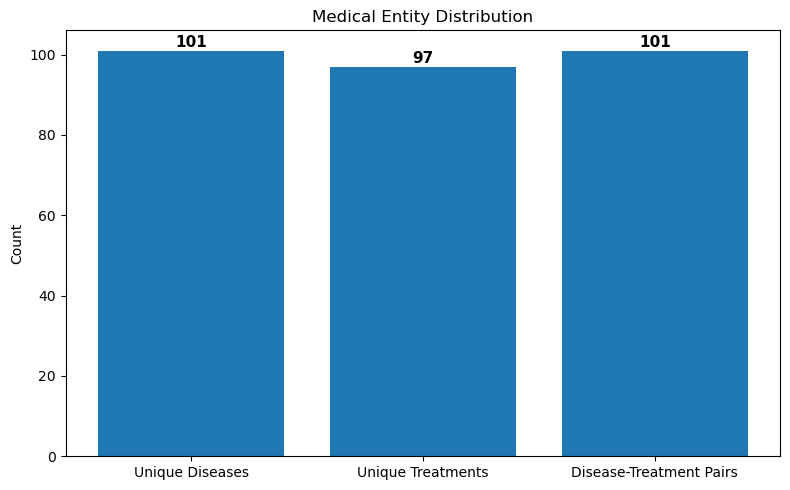

In [114]:
import matplotlib.pyplot as plt


# Calculate counts
num_diseases = disease_treatment_df['Disease'].nunique()
num_treatments = disease_treatment_df['Treatments'].apply(str).nunique()
num_pairs = len(disease_treatment_df)

counts = {
    'Unique Diseases': num_diseases,
    'Unique Treatments': num_treatments,
    'Disease-Treatment Pairs': num_pairs
}


plt.figure(figsize=(8,5))

bars = plt.bar(counts.keys(), counts.values())

plt.title('Medical Entity Distribution')
plt.ylabel('Count')

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f'{int(height)}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

plt.tight_layout()
plt.show()






In [106]:
print(disease_treatment_df.head()
     )

                                  Disease  \
0  hereditary retinoblastoma                
1  myocardial infarction                    
2  unstable angina                          
3  coronary-artery disease                  
4  primary pulmonary hypertension ( PPH )   

                                                            Treatments  
0  [radiotherapy]                                                       
1  [warfarin with 80 mg aspirin , or 1 mg warfarin with 80 mg aspirin]  
2  [roxithromycin]                                                      
3  [Antichlamydial antibiotics]                                         
4  [fenfluramines]                                                      


#### 8.2 Predict the treatment for the disease name: 'hereditary retinoblastoma'

In [65]:
disease='hereditary retinoblastoma'

print("Disease: ",disease)
print("Treatment:", diseases_and_treatments.get('hereditary retinoblastoma'))

Disease:  hereditary retinoblastoma
Treatment: ['radiotherapy']
